# Mission_12_[_Flight_Case]_RocketPy_v1.

In [27]:
import difflib
from datetime import date, timedelta
from rocketpy import Environment, SolidMotor, Rocket, Flight, Function

## Corretor Fuzzy

In [40]:
def corretor_fuzzy(input_usuario, lista_valida, nome_parametro = "Parâmetro", cutoff = 0.5, verbose = False):
    
    """
    Projeto de Simulação de Trajetória - RocketPy
    Latin American Space Challenge (LASC) 2026

    Autor: Gabriel Pozzobon de Oliveira
    Equipe: Kosmos Rocketry
    Descrição:
    Atua como um filtro de segurança computacional para corrigir erros de 
    digitação (typos) e inconsistências de maiúsculas/minúsculas nas entradas 
    do usuário. Garante que as classes do RocketPy recebam as strings 
    exatamente no formato estrito exigido pelo framework.

    Mecânica de Funcionamento (3 Camadas):
    1. Normalização: Converte o input e a lista válida para minúsculas e 
       tenta um match exato (resolvendo erros de "Caps Lock").
    2. Motor Fuzzy: Caso falhe, usa o algoritmo de Levenshtein (difflib) 
       para buscar a opção estatisticamente mais semelhante na lista.
    3. Fallback: Se a semelhança for menor que o limite de corte (cutoff), 
       repassa a palavra original limpa para não bloquear bibliotecas futuras.

    Parâmetros:
    - input_usuario (str): A string bruta repassada pela função original.
    - lista_valida (list): Lista de strings oficiais que o sistema espera receber.
    - nome_parametro (str): Nome da variável analisada. Útil para impressão de logs.
    - cutoff (float): Nível de rigor da correção (de 0.0 a 1.0). Um cutoff de 
                      0.5 exige no mínimo 50% de similaridade (Padrão: 0.5).
    - verbose (bool): Se True, notifica no terminal se uma correção autônoma 
                      foi aplicada (Padrão: False).

    Retorno:
    - (str): A string validada com a capitalização (maiúsculas/minúsculas) 
             oficial da lista. Em caso de falha profunda, retorna o original.

    Guia de Manutenção (Como adicionar novos parâmetros/opções):
    Esta função é universal e "agnóstica" (não sabe se está corrigindo motores 
    ou climas). Portanto, você NUNCA precisa alterar o código desta função.
    
    Para que o corretor passe a reconhecer um novo motor chamado "MOON", 
    basta ir na função `set_motor` e adicionar a palavra na lista local:
    De:  opcoes_motor = ["BATES", "ESTRELA"]
    Para: opcoes_motor = ["BATES", "ESTRELA", "MOON"]
    """
    
    input_limpo = str(input_usuario).strip().lower()
    mapa_lower = {opt.lower(): opt for opt in lista_valida}

    # 1. Match exato (ignora apenas maiúsculas/minúsculas)
    if input_limpo in mapa_lower:
        return mapa_lower[input_limpo]

    # 2. Busca aproximada (Fuzzy)
    match = difflib.get_close_matches(input_limpo, mapa_lower.keys(), n=1, cutoff=cutoff)
    if match:
        correcao = mapa_lower[match[0]]
        if verbose:
            print(f"[Corretor] '{nome_parametro}' ajustado de '{input_usuario}' para '{correcao}'.")
        return correcao

    # 3. Fallback: Devolve o original se o erro for muito grande
    return str(input_usuario).strip()

## Environment

In [101]:
from datetime import date, timedelta
from rocketpy import Environment

def set_env(days_to_launch = 1, hour = 14, atm_type = "Windy", atm_file = "ECMWF", max_altitude = 1800, datum = "SIRGAS2000", verbose = False):
    
    """
    Projeto de Simulação de Trajetória - RocketPy
    Latin American Space Challenge (LASC) 2026

    Autor: Gabriel Pozzobon de Oliveira
    Equipe: Kosmos Rocketry
    Descrição: Script para configuração dinâmica do ambiente de lançamento
    (clima, topografia e coordenadas) no Sugarcane Launch Range.
            
    Parâmetros:
    - days_to_launch (int): Dias para o lançamento (Padrão: 1).
    - hour (int): Hora do lançamento (fuso de São Paulo) (Padrão: 14h).
    - atm_type (str): Fonte dos dados. Ex: "Windy", "forecast" ou "standard_atmosphere".
    - atm_file (str): O modelo meteorológico. Ex: "ECMWF", "GFS", "ICON".
    - max_altitude (float): Altitude máxima (m) para processamento de dados climáticos. 
                            O Padrão é 1800 m, representando o apogeu estimado do DEIMOS II 
                            (1198 m) acrescido de uma margem de segurança de ~50%.
   - datum (str): Modelo elipsoidal de referência. Ex: "SIRGAS2000", "WGS84", "SAD69". 
                   O padrão é "SIRGAS2000", pois é o modelo geodésico oficial adotado 
                   no Brasil (ideal para a LASC).
    - verbose (bool): Se True, exibe logs e gráficos detalhados.
    """

    # ==========================================
    # DICIONÁRIO DE VALIDAÇÃO DE PARÂMETROS
    # ==========================================
    
    opcoes_atm_type = ["Windy", "forecast", "standard_atmosphere", "Reanalysis", "Ensemble"]
    opcoes_atm_file = ["ECMWF", "GFS", "ICON", "NAM"] 
    opcoes_datum = ["SAD69", "WGS84", "NAD83", "SIRGAS2000"]

    # Aplicando o corretor global (Fuzzy Matching)
    atm_type_limpo = corretor_fuzzy(atm_type, opcoes_atm_type, "atm_type", verbose = verbose)
    atm_file_limpo = corretor_fuzzy(atm_file, opcoes_atm_file, "atm_file", verbose = verbose)
    datum_type_limpo = corretor_fuzzy(datum, opcoes_datum, "datum", verbose = verbose)
    
    # ==========================================
    # LOG DE INICIALIZAÇÃO
    # ==========================================

    if days_to_launch == 0:
        dia_texto = "hoje"
    elif days_to_launch == 1:
        dia_texto = "amanhã"
    else:
        dia_texto = f"daqui a {days_to_launch} dias"
        
    if verbose:
        print(f"Configurando ambiente para {dia_texto} à(s) {hour}h...")
            
    # ==========================================
    # 1. CONFIGURAÇÃO DE COORDENADAS E DATUM
    # ==========================================
    
    env = Environment(
        latitude =- 21.940143, 
        longitude =- 48.942817, 
        datum = datum_type_limpo
    )
    
    # ==========================================
    # 2. CONFIGURAÇÃO DE DATA E HORA
    # ==========================================
    
    target_date = date.today() + timedelta(days = days_to_launch)
    date_info = (target_date.year, target_date.month, target_date.day, hour)
    env.set_date(date_info, timezone = "America/Sao_Paulo")
    
    # ==========================================
    # 3. PREVISÃO ATMOSFÉRICA DINÂMICA
    # ==========================================
    
    if verbose:
        print(f"Baixando dados atmosféricos via {atm_type_limpo} (Modelo: {atm_file_limpo})...")
        
    env.set_atmospheric_model(type = atm_type_limpo, file = atm_file_limpo)
    
    # ==========================================
    # 4. CONFIGURAÇÃO TOPOGRÁFICA E OTIMIZAÇÃO
    # ==========================================
    
    # Truncagem de altitude para visualização otimizada de gráficos
    env.max_expected_altitude = max_altitude
    
    if verbose:
        print(f"Carregando perfil topográfico e limitando altitude para {max_altitude}m...")
        
    env.set_topographic_profile(
        type = "NASADEM_HGT",
        file = "NASADEM_NC_s22w049.nc", 
        dictionary = "netCDF4",
        crs = None
    )
    
    elevation = env.get_elevation_from_topographic_profile(env.latitude, env.longitude)
    env.set_elevation(elevation)
    
    if verbose:
        print(f"Elevação da base definida para: {elevation:.2f} metros ASL.")
    
    # ==========================================
    # 5. EXIBIÇÃO DE DADOS E GRÁFICOS
    # ==========================================
    
    if verbose:
        print("\n--- Resumo do Ambiente ---")
        env.info()
        print("\n--- Gerando Gráficos Atmosféricos ---\n")
        env.plots.atmospheric_model()
        print("\n--- Ambiente de Lançamento configurado com sucesso ---")
    
    return env

## Motor

In [97]:
def set_motor(motor_name = "BATES", interpolation_method = "linear", grain_separation = 0.0, verbose = False):
    
    """
    Projeto de Simulação de Trajetória - RocketPy
    Latin American Space Challenge (LASC) 2026

    Autor: Gabriel Pozzobon de Oliveira
    Equipe: Kosmos Rocketry
    Descrição: Script para configuração e instanciação do sistema de propulsão sólida.
               Carrega propriedades físicas (massa, inércia, geometria) e a curva de empuxo.
            
    Executa a montagem do motor baseada na geometria de grão escolhida.
    Opções de motor: 'BATES', 'ESTRELA'

    Parâmetros:
    - motor_name (str): A configuração do grão que você quer rodar (Padrão: "BATES").
    - interpolation_method (str): Método para suavizar a curva de empuxo lida do arquivo .eng. 
                                  Ex: "linear", "spline" ou "akima" (Padrão: "linear").
    - grain_separation (float): Distância (em metros) entre os grãos de propelente, útil 
                                para simular O-rings ou espaçadores térmicos (Padrão: 0.0).
    - verbose (bool): Se True, exibe os logs e gráficos detalhados. (Padrão: False).

    Notas Técnicas e Manutenção:
    - FONTES CAD: Massa (dry_mass), inércia (dry_inertia), densidade e CG extraídos 
                  do "FAISCA POWER-DEIMOS II-Atual".
    - FONTES OPENMOTOR: Tempos de queima e geometrias internas baseadas nos arquivos 
                        'FAISCA95' e 'FAISCA STAR 28cm.'.
    - MÉTODO AKIMA: Mandatório utilizar Time Step de 0.01s no export do openMotor. 
                    Passos de 0.03s causam instabilidade numérica neste método.
    - GEOMETRIA ESTRELA: Devido à limitação de geometria cilíndrica do RocketPy, o motor 
                         ESTRELA utiliza um raio interno equivalente baseado no volume real.
    - COORDENADAS: Posição do bocal definida como origem (0,0,0) para este componente, 
                   seguindo a orientação 'nozzle_to_combustion_chamber'.
    """
    
    # ==========================================
    # NORMALIZAÇÃO E MAPEAMENTO DE INPUTS
    # ==========================================
    
    opcoes_motor = ["BATES", "ESTRELA"]
    opcoes_interp = ["linear", "spline", "akima"]

    motor_limpo = corretor_fuzzy(motor_name, opcoes_motor, "motor_name", verbose = verbose)
    interp_limpa = corretor_fuzzy(interpolation_method, opcoes_interp, "interpolation_method", verbose = verbose).lower()
    
    if verbose:
        print(f"Carregando Motor: {motor_limpo} (Interpolação: {interp_limpa})...\n")

    # ==========================================
    # 1. INSTANCIAÇÃO DO MOTOR
    # ==========================================
    
    if motor_limpo == 'BATES':
        motor = SolidMotor(
            thrust_source = r"empuxo_faisca_bates_v1.1.eng",
            dry_mass = 0.337548,                            # [Fonte: Input CAD Fusion 360 Atualizado]
            dry_inertia = (0.1483, 0.1486, 0.004305),       # [Fonte: image_bda4f0.png - Centro de Massa (kg*m^2)]
            nozzle_radius = 0.01185,                        # [Fonte: openMotor 'FAISCA 2B' - pol para m]
            grain_number = 3,                               
            
            grain_density = 1712.73,                        # [Fonte: Conversão KNSB lb/in^3 para kg/m^3]
            grain_outer_radius = 0.02100,                   # [Fonte: Geometria do Grão BATES]
            grain_initial_inner_radius = 0.00635,           # [Fonte: Geometria do Grão BATES]
            grain_initial_height = 0.11000,                 # [Fonte: Geometria do Grão BATES]
            grain_separation = 0.003,                       # [Fonte: Input 3mm para m]
            
            grains_center_of_mass_position = 0.194148,      # [Fonte: Input CAD (194.148 mm convertido para positivo em m)]
            center_of_dry_mass_position = 0.190255,         # [Fonte: Input CAD (190.255 mm convertido para positivo em m)]
            
            nozzle_position = 0,                            # Origem do sistema de coordenadas do motor
            burn_time = 1.53,                               # [Fonte: Input atualizado do openMotor]
            throat_radius = 0.00475,                        # [Fonte: openMotor 'FAISCA 2B' - pol para m]
            coordinate_system_orientation = "nozzle_to_combustion_chamber",
            interpolation_method = interp_limpa
        )

    elif motor_limpo == 'ESTRELA':
        motor = SolidMotor(
            thrust_source = r"empuxo_faisca_star_v1.eng",
            dry_mass = 0.425007,                            # [Fonte: CAD Fusion 360]
            dry_inertia = (0.004261, 0.004261, 0.000218),   # [Fonte: CAD Fusion 360]
            nozzle_radius = 0.01185,                        # [Fonte: openMotor 'FAISCA STAR 28cm.' - pol para m]
            grain_number = 2,                               # [Fonte: openMotor 'FAISCA STAR 28cm.']
            grain_density = 1750,                           # [Fonte: CAD Fusion 360]
            grain_outer_radius = 0.0213125,                 # [Fonte: openMotor 'FAISCA STAR 28cm.' - diam. pol para raio m]
            grain_initial_inner_radius = 0.00704,           # [Fonte: openMotor 'FAISCA STAR 28cm.' - Equivalência de Volume (RocketPy s/ suporte à estrela)]
            grain_initial_height = 0.105,                   # [Fonte: openMotor 'FAISCA STAR 28cm.' - pol para m]
            grain_separation = grain_separation,            # [Fonte: CAD Fusion 360]
            grains_center_of_mass_position = 0.1075,        # [Fonte: CAD Fusion 360]
            center_of_dry_mass_position = 0.145,            # [Fonte: CAD Fusion 360]
            nozzle_position = 0,                            # Origem do sistema de coordenadas
            burn_time = 1.48,                               # [Fonte: openMotor 'FAISCA STAR 28cm.']
            throat_radius = 0.00475,                        # [Fonte: openMotor 'FAISCA STAR 28cm.' - diam. pol para raio m]
            coordinate_system_orientation = "nozzle_to_combustion_chamber",
            interpolation_method = interp_limpa
        )
        
    else:
        print(f"Erro Crítico: Motor '{motor_name}' não suportado. Fallback acionado pelo corretor falhou.")
        return None

    # ==========================================
    # 2. EXIBIÇÃO DE DADOS (APLICAÇÃO DO DRY)
    # ==========================================
    
    if verbose:
        print("\n--- Resumo do Motor ---\n")
        motor.all_info()
        print(f"\n--- Motor {motor_limpo} carregado com sucesso ---")
        
    return motor

## Rocket

In [98]:
def set_rocket(motor_type = "BATES", flight_case = "nominal", lag_paraquedas = 0.67, custom_altitude = 300, drag_source = "RASAero", verbose = False):
    
    """
    Projeto de Simulação de Trajetória - RocketPy
    Latin American Space Challenge (LASC) 2026

    Autor: Gabriel Pozzobon de Oliveira
    Equipe: Kosmos Rocketry
    Descrição: Script para configuração da estrutura física e das propriedades
               aerodinâmicas do foguete DEIMOS II. Carrega a curva de arrasto (drag curve)
               correspondente ao tipo de motor selecionado para manter a precisão do voo.

    Parâmetros:
    - motor_type (str): O tipo de grão do motor que será utilizado no voo.
                        Opções válidas: 'BATES' ou 'ESTRELA'. (Padrão: "BATES")
    - flight_case (str): O cenário de simulação para o acionamento dos paraquedas.
                         Opções: 'nominal', 'ballistic', 'main_apogee', 'custom' 
                         (Padrão: "nominal").
    - lag_paraquedas (float): Tempo (em segundos) estimado para a abertura e 
                              inflação física do paraquedas (Padrão: 0.67).
    - custom_altitude (float): Altitude (em metros) de acionamento do paraquedas, 
                               usada exclusivamente no cenário 'custom' (Padrão: 300).
    - drag_source (str): Define a origem do arquivo CSV de arrasto aerodinâmico.
                         Opções válidas: 'RASAero' ou 'OpenRocket'. (Padrão: "RASAero").
    - verbose (bool): Se True, exibe os logs detalhados de montagem da estrutura. 

    Notas Técnicas e Manutenção:
    - DEPENDÊNCIA: A função set_motor() deve ser executada obrigatoriamente antes 
                   para gerar o objeto do motor que será acoplado.
    - GEOMETRIA E ARRASTO: A Drag Curve deve ser reavaliada em qualquer mudança na 
                           geometria externa (coifa, aletas ou fuselagem).
    - MELHORIA FUTURA: Recomenda-se realizar CFD para curvas distintas de 'motor_on' 
                       e 'motor_off', aumentando a fidelidade da simulação.
    - DADOS FÍSICOS: Massa (2.529 kg) e CG (0.560 m) extraídos do DeimosII_v3.1 
                     via OpenRocket.
    - VALIDAÇÃO PENDENTE: As inércias (I11, I22, I33) são estimativas baseadas no 
                          CAD preliminar (Assembly - Deimos II - Atual) e necessitam 
                          de validação final.
    - REFERÊNCIA: O sistema de coordenadas adota a ponta do nariz (nosecone) como 
                  origem (0,0,0), seguindo a orientação 'nose_to_tail'.
    - RECUPERAÇÃO: Parâmetros físicos dos paraquedas revisados em 03/05/26.
    """
    
    # ==========================================
    # NORMALIZAÇÃO E MAPEAMENTO DE INPUTS
    # ==========================================
    
    opcoes_motor = ["BATES", "ESTRELA"]
    opcoes_flight_case = ["nominal", "ballistic", "main_apogee", "custom"]
    opcoes_drag = ["RASAero", "OpenRocket"]

    motor_type_limpo = corretor_fuzzy(motor_type, opcoes_motor, "motor_type", verbose=verbose)
    
    # Forçamos o .lower() aqui no final pois a lógica dos Ifs do paraquedas abaixo usa minúsculas
    flight_case_limpo = corretor_fuzzy(flight_case, opcoes_flight_case, "flight_case", verbose=verbose).lower()
    
    drag_source_limpo = corretor_fuzzy(drag_source, opcoes_drag, "drag_source", verbose=verbose)
    
    # ==========================================
    # 1. SELEÇÃO DO PERFIL AERODINÂMICO (ARRASTO) 
    # ==========================================
    
    if drag_source_limpo == "RASAero":
        drag_file = r"drag_curve_deimos2_RAS_v1.csv"
    else:
        drag_file = r"drag_curve_deimos2_ORK_v1.2.csv"
    
    # Criando o objeto Function com Spline
    drag_curve_suavizada = Function(
        drag_file, 
        interpolation="spline",
        extrapolation="constant" # Mantém o último valor de Cd caso o foguete passe do Mach máximo do CSV
    )

    if verbose:
        print(f"Configurando aerodinâmica externa unificada do DEIMOS II...")
        print(f"Fonte de dados de arrasto selecionada: {drag_source_limpo}")
        print(f"Arquivo de arrasto carregado e suavizado via Spline: {drag_file}")
        
    # ==========================================
    # 2. INSTANCIAÇÃO DA ESTRUTURA FÍSICA E MOTOR
    # ==========================================
    
    if verbose:
        print("Montando parâmetros estruturais do foguete (DeimosII_v3.1)...") 
    
    deimos_ii = Rocket(
        radius = 0.0683 / 2,                  # Raio externo da fuselagem (m)
        mass = 2529 / 1000,                   # Massa vazia (kg) [Fonte: OpenRocket]
        inertia = (0.3177, 0.3146, 0.00532),  # Inércias I11, I22, I33 (kg·m²) [Fonte: Fusion 360]
        power_off_drag = drag_curve_suavizada, 
        power_on_drag = drag_curve_suavizada,  
        center_of_mass_without_motor = 0.560, # Posição do CG vazio (m) [Fonte: OpenRocket]
        coordinate_system_orientation = "nose_to_tail" 
    )
    
    # ==========================================
    # INSTANCIAÇÃO E ACOPLAMENTO INTERNO DO MOTOR
    # ==========================================
    
    if verbose:
        print(f"Acoplando o sistema de propulsão interno ({motor_type_limpo})...")

    # O motor é instanciado em modo silencioso (verbose=False) para não poluir o terminal, 
    # já que o resumo final do foguete (deimos_ii.all_info()) vai englobar tudo.
    motor_obj = set_motor(motor_name = motor_type_limpo, verbose = False)
        
    # Variável de posicionamento estrutural: 
    posicao_do_bocal = 1.082 
    deimos_ii.add_motor(motor_obj, position=posicao_do_bocal)

    # ==========================================
    # 3. SUPERFÍCIES AERODINÂMICAS
    # ==========================================
    
    if verbose:
        print("Adicionando superfícies aerodinâmicas (Coifa, Aletas e Guias)...")

    # 3.1 Coifa (Nose Cone)
    nose = deimos_ii.add_nose(
        name = "Coifa_Eliptica",
        length = 0.098,         # Comprimento da coifa em metros (9,8 cm)
        kind = "elliptical",    # Perfil aerodinâmico elíptico
        position=0.0
    )

    # 3.2 Aletas (Trapezoidal Fins)
    fins = deimos_ii.add_trapezoidal_fins(
        n = 3,                  # Número de aletas
        root_chord = 0.100,     # Comprimento da base da aleta colada no tubo (100 mm)
        tip_chord = 0.035,      # Comprimento do topo da aleta (35 mm)
        span = 0.088,           # Altura de UMA aleta (8.8 mm)
        sweep_length = 0.120,   # Distância horizontal da raiz até a ponta (120 mm)
        position = 0.921        # Posição da quina superior da aleta (m)
    )

    # 3.3 Redução de Cauda (Boat Tail)
    tail = deimos_ii.add_tail(
        name = "Boat Tail (Semi-Triangular)",
        top_radius = 0.0683 / 2,     # Raio superior colado no tubo (34,15 mm)
        bottom_radius = 0.0476 / 2,  # Raio inferior do final da cauda (23,8 mm)
        length = 0.066,               # Comprimento da peça (66 mm)
        position = 1.021
    )

    # 3.4 Botões de Guia (Rail Buttons)
    buttons = deimos_ii.set_rail_buttons(
        upper_button_position=0.325,
        lower_button_position=1.005,
        angular_position=180
    )
    
    # ==========================================
    # 4. SISTEMA DE RECUPERAÇÃO
    # ==========================================
    
    if verbose:
        print("\nConfigurando o Sistema de Recuperação...")
    
    if flight_case_limpo == 'ballistic':
        if verbose:
            print("-> Caso BALÍSTICO: Nenhum paraquedas será acionado no Deimos II.")
    
    else:
        main_cd_s = 0.9817    # Coeficiente de Arrasto * Área [m²]
        main_radius = 0.5     # Raio da copa inflada [m]
        main_porosity = 0.2   # Porosidade geométrica [adimensional]
        
        if flight_case_limpo == 'nominal':
            lag_fisico_estimado = 0.67 
            lag_nominal_fixo = lag_fisico_estimado + 1.0 # 0.67s de abertura + 1.0s de delay
            
            main = deimos_ii.add_parachute(
                name="Main",
                cd_s=main_cd_s,
                trigger="apogee",
                lag=lag_nominal_fixo,        
                radius=main_radius,
                porosity=main_porosity
            )
            if verbose:
                print(f"-> Paraquedas MAIN configurado (Nominal: Apogeu | Lag Fixo: {lag_nominal_fixo}s).")
            
        elif flight_case_limpo == 'main_apogee':
            lag_fisico_base = 0.67 
            
            main = deimos_ii.add_parachute(
                name="Main",
                cd_s=main_cd_s,
                trigger="apogee",
                lag=lag_fisico_base,
                radius=main_radius,
                porosity=main_porosity
            )
            if verbose:
                print(f"-> Paraquedas MAIN configurado (Abertura Imediata no Apogeu | Lag Fixo: {lag_fisico_base}s).")
            
        elif flight_case_limpo == 'custom':
            main = deimos_ii.add_parachute(
                name="Main",
                cd_s=main_cd_s,
                trigger=custom_altitude, 
                lag=lag_paraquedas,
                radius=main_radius,
                porosity=main_porosity
            )
            if verbose:
                print(f"-> Paraquedas MAIN configurado (Customizado: {custom_altitude}m | Lag: {lag_paraquedas}s).")
            
        else:
            print(f"-> AVISO: Caso de voo '{flight_case}' não reconhecido para a configuração de paraquedas.")

    # ==========================================
    # 5. EXIBIÇÃO DE DADOS E GRÁFICOS
    # ==========================================

    if verbose:
        print("\n--- Resumo do Foguete ---\n")
        deimos_ii.all_info()
        print("\n--- Estrutura, Aerodinâmica e Recuperação do DEIMOS II carregadas com sucesso ---")
    
    return deimos_ii

In [99]:
def set_flight(motor_type = "BATES", flight_case = "nominal", lag_paraquedas = 0.67, custom_altitude = 300, drag_source = "RASAero", verbose = False):
    print("\n" + "="*60)
    print("      INICIANDO SIMULAÇÃO INTEGRADA      ")
    print("="*60)
    
    # Instanciando o ambiente
    env = set_env(days_to_launch=1, hour=14, verbose=verbose)
    
    # Instanciando a estrutura física repassando TODOS os parâmetros atualizados
    rocket = set_rocket(
        motor_type=motor_type, 
        flight_case=flight_case,
        lag_paraquedas=lag_paraquedas,
        custom_altitude=custom_altitude,
        drag_source=drag_source,
        verbose=verbose
    )
    
    print("="*60)
    print("                 LANÇANDO INTEGRALMENTE: DEIMOS II               ")
    print("="*60)
    
    # Criando e rodando a simulação
    flight_custom = Flight(
        rocket=rocket,
        environment=env,
        rail_length=5.2,
        inclination=85,
        heading=90
    )
    
    if verbose:
        print("\n" + "#"*40)
        print("          RELATÓRIO FINAL DE VOO (POST-FLIGHT)          ")
        print("#"*40)
        flight_custom.info()
        
        print("\n[Plot] Renderizando curvas de estabilidade e dinâmica 3D...")
        flight_custom.plots.trajectory_3d()
        
    print("\n[Sucesso] Pipeline executado sem falhas. Dados consolidados.")
    return flight_custom

Configurando ambiente para amanhã à(s) 14h...
Baixando dados atmosféricos via Windy (Modelo: ECMWF)...
Carregando perfil topográfico e limitando altitude para 1800m...
Region covered by the Topographical file: 
Latitude from -22.000000° to -21.000000°
Longitude from -49.000000° to -48.000000°
Elevação da base definida para: 489.00 metros ASL.

--- Resumo do Ambiente ---

Gravity Details

Acceleration of gravity at surface level:    9.7860 m/s²
Acceleration of gravity at  14.219 km (ASL): 9.7438 m/s²


Launch Site Details

Launch Date: 2026-08-09 17:00:00 UTC | 2026-08-09 14:00:00 America/Sao_Paulo
Launch Site Latitude: -21.94014°
Launch Site Longitude: -48.94282°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 92615.18 W    7568555.32 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 489.0 m


Atmospheric Model Details

Atmospheric Model Type: Windy
Windy Maximum Height: 14.219 km

Surface Atmospheric Conditions

Surface Wind Speed: 5.34 m/s
Surface Wind Direction: 30

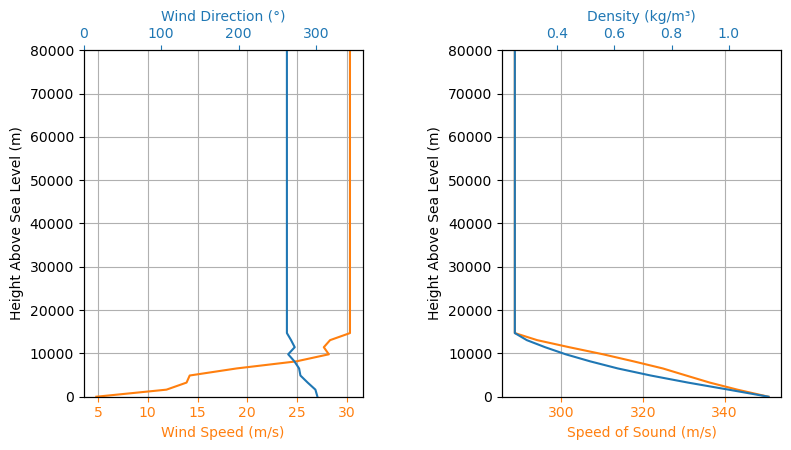


--- Gerando Gráficos Atmosféricos ---



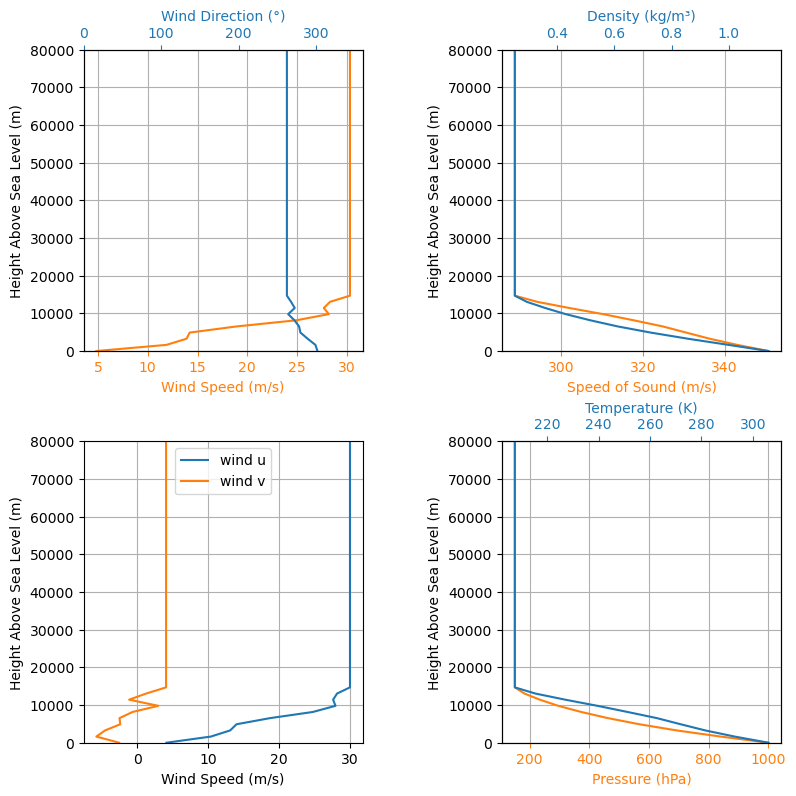


--- Ambiente de Lançamento configurado com sucesso ---


In [100]:
env = set_env(max_altitude = 1800 , verbose = True)
